# Principal Component Analysis (PCA) from Scratch
## Formative Assignment — Advanced Linear Algebra
### Use case: Economic activity & population pressure across African countries

**Dataset — African Development Indicators (57 countries, 20 columns).**
Sourced from World Bank / CIA World Factbook country indicators and filtered to the
two African regions (*Northern Africa*, *Sub-Saharan Africa*). It satisfies every data
requirement of the brief:

| Requirement | This dataset |
|---|---|
| ≥ 7 columns | **20 columns** (18 numeric + 2 non-numeric) |
| Missing / NaN values | **24 missing values** across 7 countries |
| ≥ 1 non-numeric column | **`Country`** and **`Region`** (both text) |
| Africanized & impactful | 57 African nations; economic activity (GDP, phones, industry, services) and population pressure (population, density, birth rate, infant mortality) |

> **Library policy.** All numerical work — imputation, standardization, covariance,
> eigendecomposition, projection and benchmarking — uses **NumPy only**.
> `matplotlib` is used *solely* to draw the required before/after plots (Step 8),
> since the brief explicitly asks for plots to be displayed.


## Imports

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("NumPy version:", np.__version__)

NumPy version: 2.4.4


## Step 1: Load the data
We read the CSV with NumPy only. The two text columns (`Country`, `Region`) are read as
strings and set aside; the 18 numeric columns form the feature matrix. Empty cells are
read as `NaN`, which we handle in Step 2.

In [ ]:
DATA_PATH = "african_development_indicators.csv"

# Column 0 = Country (text), column 1 = Region (text), columns 2..19 = numeric features
with open(DATA_PATH, encoding="utf-8") as f:
    header = f.readline().strip().split(",")
feature_names = header[2:]
numeric_cols = tuple(range(2, len(header)))

country = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1, usecols=(0,),
                        dtype=str, encoding="utf-8", autostrip=True)
region  = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1, usecols=(1,),
                        dtype=str, encoding="utf-8", autostrip=True)
X_raw   = np.genfromtxt(DATA_PATH, delimiter=",", skip_header=1, usecols=numeric_cols,
                        dtype=float, encoding="utf-8")   # empty -> NaN

print("Countries loaded :", country.shape[0])
print("Feature matrix   :", X_raw.shape, "(rows = countries, cols = numeric features)")
print("Non-numeric cols :", header[0], "and", header[1])
print("Regions          :", np.unique(region))
print("\nFirst 5 countries:", country[:5])
print("\nNumeric features :")
for i, name in enumerate(feature_names):
    print(f"  {i:2d}. {name}")

Countries loaded : 57
Feature matrix   : (57, 18) (rows = countries, cols = numeric features)
Non-numeric cols : Country and Region
Regions          : ['NORTHERN AFRICA' 'SUB-SAHARAN AFRICA']

First 5 countries: ['Algeria' 'Angola' 'Benin' 'Botswana' 'Burkina Faso']

Numeric features :
   0. Population
   1. Area (sq. mi.)
   2. Pop. Density (per sq. mi.)
   3. Coastline (coast/area ratio)
   4. Net migration
   5. Infant mortality (per 1000 births)
   6. GDP ($ per capita)
   7. Literacy (%)
   8. Phones (per 1000)
   9. Arable (%)
  10. Crops (%)
  11. Other (%)
  12. Climate
  13. Birthrate
  14. Deathrate
  15. Agriculture
  16. Industry
  17. Service


## Step 2: Handle missing values & the non-numeric column

**Non-numeric column.** PCA operates on numeric features, so `Country` (a unique
identifier) and `Region` are removed from the feature matrix. We *keep* `Region` aside
as a label, purely to colour the visualisation in Step 8.

**Missing values.** We impute each `NaN` with its **column mean** (computed with
`np.nanmean`, which ignores `NaN`s). Mean imputation keeps every country in the analysis
and does not change a feature's mean, so it has minimal effect on the variances PCA relies
on.

In [3]:
# --- inspect missing values ---
nan_per_col = np.isnan(X_raw).sum(axis=0)
print("Missing values per feature (only those with gaps):")
for name, c in zip(feature_names, nan_per_col):
    if c:
        print(f"  {name:35s}: {int(c)}")
print("Total missing values :", int(np.isnan(X_raw).sum()))
print("Countries with a gap :", int(np.isnan(X_raw).any(axis=1).sum()))

# --- mean imputation (NumPy only) ---
col_means = np.nanmean(X_raw, axis=0)
missing_idx = np.where(np.isnan(X_raw))
X = X_raw.copy()
X[missing_idx] = np.take(col_means, missing_idx[1])

print("\nMissing values after imputation:", int(np.isnan(X).sum()))
print("Clean feature matrix shape       :", X.shape)

Missing values per feature (only those with gaps):
  Net migration                      : 1
  Infant mortality (per 1000 births) : 1
  GDP ($ per capita)                 : 1
  Literacy (%)                       : 2
  Phones (per 1000)                  : 1
  Arable (%)                         : 1
  Crops (%)                          : 1
  Other (%)                          : 1
  Climate                            : 5
  Birthrate                          : 1
  Deathrate                          : 1
  Agriculture                        : 3
  Industry                           : 3
  Service                            : 2
Total missing values : 24
Countries with a gap : 7

Missing values after imputation: 0
Clean feature matrix shape       : (57, 18)


## Step 1 (cont.): Standardize the data
Standardization rescales every feature to mean $0$ and standard deviation $1$ using
$$z = \frac{x - \mu}{\sigma}$$
exactly as in the reference image. This is essential for PCA: without it, large-scale
features (e.g. `Population` in the millions) would dominate the covariance purely because
of their units, not because they carry more information.

In [4]:
# z = (x - mu) / sigma   (population std, ddof=0)
mean = X.mean(axis=0)
std  = X.std(axis=0)
std[std == 0] = 1.0                      # guard against divide-by-zero

standardized_data = (X - mean) / std     # NumPy only — no sklearn
print("Mean of standardized features (~0):", standardized_data.mean(axis=0).round(6)[:6], "...")
print("Std  of standardized features (~1):", standardized_data.std(axis=0).round(6)[:6], "...")
standardized_data[:5]                    # first few rows of standardized data

Mean of standardized features (~0): [ 0. -0.  0.  0. -0.  0.] ...
Std  of standardized features (~1): [1. 1. 1. 1. 1. 1.] ...


array([[ 0.7191,  2.9532, -0.5935, -0.286 , -0.021 , -1.3015,  1.2919,  0.3843,  0.3753, -0.6886, -0.4417,  0.7346,
        -1.7165, -1.8045, -1.4945, -0.9782,  1.9644, -1.0576],
       [-0.1634,  1.1404, -0.6269, -0.2803,  0.1561,  3.3675, -0.2676, -1.1399, -0.4914, -0.7574, -0.443 ,  0.7868,
         0.    ,  1.0724,  1.5471, -1.0071,  2.3223, -1.4247],
       [-0.3443, -0.6708, -0.1373, -0.2816,  0.1561,  0.2724, -0.5719, -1.1997, -0.468 ,  0.5747, -0.1651, -0.3489,
         0.2893,  0.4285, -0.3129,  0.2677, -0.8862,  0.6931],
       [-0.6084,  0.1082, -0.684 , -0.2885,  0.1561, -0.6142,  2.433 ,  0.9178,  0.4049, -0.9071, -0.4726,  0.9135,
        -1.7165, -1.1935,  2.37  , -1.4244,  1.1561,  0.4178],
       [-0.0881, -0.4128, -0.2929, -0.2885,  0.1561,  0.6388, -0.5719, -1.9781, -0.5013,  0.2644, -0.4494,  0.0244,
         0.2893,  1.1248,  0.2118,  0.3025, -0.5284,  0.2413]])

## Step 3: Calculate the covariance matrix
For standardized data $Z$ with $n$ rows, the (sample) covariance matrix is
$$\Sigma = \frac{1}{n-1}\,Z^{\top}Z.$$

**Why do we compute the covariance matrix? (≥ 2 reasons)**
PCA searches for the directions of greatest variance, and the covariance matrix is the
single object that encodes that variance structure. **(1)** Its diagonal holds each
feature's variance while its off-diagonals measure how features move together, exposing
redundancy/correlation between features. **(2)** Its eigenvectors *are* the principal-component
axes and its eigenvalues give the variance along each axis, so eigendecomposing it is
precisely what produces PCA's new, uncorrelated coordinate system.

In [5]:
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)
print("Covariance matrix shape:", cov_matrix.shape)
cov_matrix

Covariance matrix shape: (18, 18)


array([[ 1.0179,  0.5066, -0.1003, -0.1897,  0.0577,  0.0617, -0.0932, -0.0249, -0.1466,  0.083 , -0.1265,  0.0004,
        -0.2111,  0.0434, -0.052 ,  0.1099,  0.0073, -0.1387],
       [ 0.5066,  1.0179, -0.3996, -0.2426,  0.0966,  0.1074,  0.0577, -0.0852, -0.1596, -0.3757, -0.3092,  0.4345,
        -0.3619,  0.0627, -0.0216,  0.0654,  0.1108, -0.205 ],
       [-0.1003, -0.3996,  1.0179,  0.3963,  0.1183, -0.3187,  0.225 ,  0.134 ,  0.3967,  0.6724,  0.3647, -0.6844,
         0.2812, -0.1408, -0.3392, -0.0623, -0.1748,  0.2799],
       [-0.1897, -0.2426,  0.3963,  1.0179, -0.2752, -0.336 ,  0.2416,  0.0548,  0.4653, -0.0397,  0.3056, -0.1216,
         0.1261, -0.2763, -0.3253, -0.2127, -0.0418,  0.3086],
       [ 0.0577,  0.0966,  0.1183, -0.2752,  1.0179,  0.2035, -0.0902, -0.1265, -0.2797,  0.0472, -0.1684,  0.048 ,
        -0.3141,  0.2756,  0.1551,  0.2403, -0.0097, -0.282 ],
       [ 0.0617,  0.1074, -0.3187, -0.336 ,  0.2035,  1.0179, -0.6163, -0.5486, -0.6929, -0.1861, -0.1928

## Step 4: Perform eigendecomposition
The covariance matrix is symmetric, so we use `np.linalg.eigh`, which is faster and
numerically more stable than `eig` and returns **real** eigenvalues/eigenvectors.
Each eigenvalue $\lambda_i$ is the variance captured along its eigenvector (a principal axis).

In [6]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Number of eigenvalues:", eigenvalues.shape[0])
print("Eigenvalues (ascending order from eigh):")
print(eigenvalues)
print("\nEigenvectors matrix shape (columns are eigenvectors):", eigenvectors.shape)
eigenvalues, eigenvectors

Number of eigenvalues: 18
Eigenvalues (ascending order from eigh):
[0.     0.0005 0.0771 0.104  0.1595 0.2433 0.323  0.4549 0.5652 0.6412 0.7427 0.8983 0.9738 1.1959 1.5635 1.6555 3.4891
 5.2338]

Eigenvectors matrix shape (columns are eigenvectors): (18, 18)


(array([0.    , 0.0005, 0.0771, 0.104 , 0.1595, 0.2433, 0.323 , 0.4549, 0.5652, 0.6412, 0.7427, 0.8983, 0.9738, 1.1959,
        1.5635, 1.6555, 3.4891, 5.2338]),
 array([[ 0.    ,  0.0025,  0.0564,  0.1149,  0.1494,  0.2119, -0.3068,  0.3199, -0.2851, -0.0993, -0.3698, -0.0085,
         -0.0525, -0.3941,  0.1397,  0.5513, -0.0585, -0.084 ],
        [-0.    ,  0.0041, -0.1944, -0.1212, -0.2317, -0.1368,  0.2601, -0.6506,  0.0414, -0.1148, -0.0197, -0.0203,
         -0.1276, -0.2414, -0.0487,  0.4474, -0.2652, -0.1448],
        [ 0.    , -0.0018, -0.0801, -0.3987,  0.4935,  0.1628,  0.3215, -0.1715, -0.2651,  0.0019, -0.1908, -0.143 ,
         -0.2116,  0.2574,  0.1789,  0.0944,  0.3058,  0.2432],
        [-0.    ,  0.0019,  0.0198,  0.0603, -0.2347, -0.4278, -0.1303,  0.0897, -0.2475, -0.2869, -0.2659, -0.1411,
         -0.5453,  0.0836, -0.3495, -0.1349,  0.0511,  0.2267],
        [-0.    ,  0.003 ,  0.0047,  0.0723, -0.2493,  0.11  , -0.3916, -0.1496, -0.2694, -0.0953,  0.3025,  0.097

## Step 5: Sort principal components
`eigh` returns eigenvalues in **ascending** order; we reverse them so the most important
component (largest eigenvalue = most variance) comes first.

**How is explained variance used in PCA?**
Each eigenvalue equals the variance captured by its component, so dividing it by the sum
of all eigenvalues gives that component's **explained-variance ratio**. Sorting components
by this ratio and taking the cumulative sum lets us keep the fewest components that still
retain a chosen share (e.g. 90%) of the total variance — that is how we decide how many
dimensions to keep.

In [7]:
sorted_indices = np.argsort(eigenvalues)[::-1]      # descending order
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted eigenvalues (descending):")
print(sorted_eigenvalues)
sorted_eigenvectors

Sorted eigenvalues (descending):
[5.2338 3.4891 1.6555 1.5635 1.1959 0.9738 0.8983 0.7427 0.6412 0.5652 0.4549 0.323  0.2433 0.1595 0.104  0.0771 0.0005
 0.    ]


array([[-0.084 , -0.0585,  0.5513,  0.1397, -0.3941, -0.0525, -0.0085, -0.3698, -0.0993, -0.2851,  0.3199, -0.3068,
         0.2119,  0.1494,  0.1149,  0.0564,  0.0025,  0.    ],
       [-0.1448, -0.2652,  0.4474, -0.0487, -0.2414, -0.1276, -0.0203, -0.0197, -0.1148,  0.0414, -0.6506,  0.2601,
        -0.1368, -0.2317, -0.1212, -0.1944,  0.0041, -0.    ],
       [ 0.2432,  0.3058,  0.0944,  0.1789,  0.2574, -0.2116, -0.143 , -0.1908,  0.0019, -0.2651, -0.1715,  0.3215,
         0.1628,  0.4935, -0.3987, -0.0801, -0.0018,  0.    ],
       [ 0.2267,  0.0511, -0.1349, -0.3495,  0.0836, -0.5453, -0.1411, -0.2659, -0.2869, -0.2475,  0.0897, -0.1303,
        -0.4278, -0.2347,  0.0603,  0.0198,  0.0019, -0.    ],
       [-0.1468,  0.0265,  0.2442,  0.3172,  0.6017, -0.1323,  0.0978,  0.3025, -0.0953, -0.2694, -0.1496, -0.3916,
         0.11  , -0.2493,  0.0723,  0.0047,  0.003 , -0.    ],
       [-0.3791,  0.0844, -0.1877,  0.0547,  0.0178, -0.0636, -0.0154, -0.3291, -0.0317, -0.0447, -0.0601

## Task 2: Dynamically select the number of components by explained variance
We compute the explained-variance ratio and its cumulative sum, then **automatically**
pick the smallest number of components whose cumulative variance reaches a chosen
threshold (here **90%**). The scree / cumulative plot makes the choice transparent.

In [8]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio per component:")
print(explained_variance_ratio.round(4))
print("\nCumulative explained variance:")
print(cumulative_variance.round(4))

# How many components for several thresholds?
print("\nComponents needed to reach a given variance threshold:")
for t in (0.80, 0.90, 0.95):
    k = int(np.searchsorted(cumulative_variance, t) + 1)
    print(f"  >= {t:.0%} variance -> {k} components")

# --- dynamic selection ---
VARIANCE_THRESHOLD = 0.90
num_components = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1)
print(f"\nSelected num_components = {num_components} "
      f"(retains {cumulative_variance[num_components-1]:.2%} of total variance)")

Explained variance ratio per component:
[0.2857 0.1904 0.0904 0.0853 0.0653 0.0532 0.049  0.0405 0.035  0.0308 0.0248 0.0176 0.0133 0.0087 0.0057 0.0042 0.
 0.    ]

Cumulative explained variance:
[0.2857 0.4761 0.5665 0.6518 0.7171 0.7702 0.8193 0.8598 0.8948 0.9256 0.9505 0.9681 0.9814 0.9901 0.9958 1.     1.
 1.    ]

Components needed to reach a given variance threshold:
  >= 80% variance -> 7 components
  >= 90% variance -> 10 components
  >= 95% variance -> 11 components

Selected num_components = 10 (retains 92.56% of total variance)


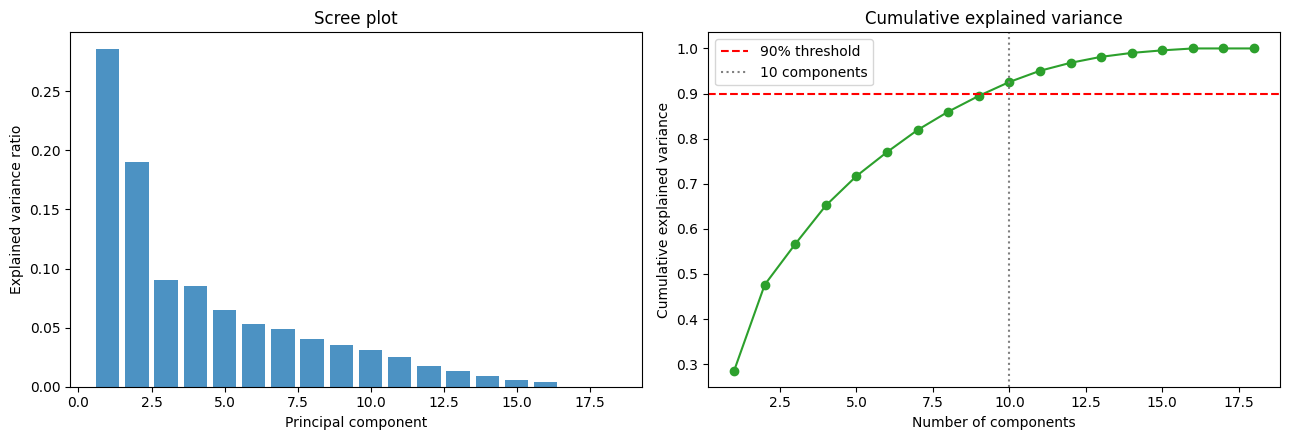

In [9]:
# Scree plot + cumulative variance curve
comp_idx = np.arange(1, len(explained_variance_ratio) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(comp_idx, explained_variance_ratio, color="tab:blue", alpha=0.8)
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Explained variance ratio")
ax[0].set_title("Scree plot")

ax[1].plot(comp_idx, cumulative_variance, "o-", color="tab:green")
ax[1].axhline(VARIANCE_THRESHOLD, color="red", ls="--",
              label=f"{VARIANCE_THRESHOLD:.0%} threshold")
ax[1].axvline(num_components, color="gray", ls=":",
              label=f"{num_components} components")
ax[1].set_xlabel("Number of components"); ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Cumulative explained variance"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 6: Project data onto the principal components
We keep the first `num_components` sorted eigenvectors as the projection matrix `W`
($d \times k$) and project the standardized data: `reduced_data = Z @ W`.

In [10]:
W = sorted_eigenvectors[:, :num_components]      # projection matrix (d x k)
reduced_data = standardized_data @ W             # (n x k) data in PCA space
print("Projection matrix W:", W.shape)
print("Reduced data       :", reduced_data.shape)
reduced_data[:5]

Projection matrix W: (18, 10)
Reduced data       : (57, 10)


array([[ 1.0045, -3.8938,  2.2957,  0.7318, -0.8746, -1.5793,  0.1213,  0.9096,  0.2284,  1.202 ],
       [-3.3003, -1.6146, -1.7275,  1.3392, -0.3175, -1.7426,  0.2787, -1.5661,  0.6589,  0.0568],
       [-0.5734,  1.4221, -0.0273, -0.6834,  0.4368,  0.6106, -0.0747, -0.0806,  1.0911,  0.1328],
       [ 0.9761, -3.5845, -0.8971,  1.0271,  1.4727,  0.829 ,  1.1057, -1.2201, -0.9894,  1.0282],
       [-1.6613,  1.0756, -0.203 , -0.6626,  0.4397,  0.1061, -0.306 , -0.607 ,  1.3126,  0.1983]])

## Step 7: Output the reduced data

In [11]:
print(f'Reduced Data Shape: {reduced_data.shape}')   # (countries, num_components)
print(f'Original numeric shape: {standardized_data.shape}')
print(f'Dimensionality reduced from {standardized_data.shape[1]} -> {reduced_data.shape[1]} features')
reduced_data[:5]

Reduced Data Shape: (57, 10)
Original numeric shape: (57, 18)
Dimensionality reduced from 18 -> 10 features


array([[ 1.0045, -3.8938,  2.2957,  0.7318, -0.8746, -1.5793,  0.1213,  0.9096,  0.2284,  1.202 ],
       [-3.3003, -1.6146, -1.7275,  1.3392, -0.3175, -1.7426,  0.2787, -1.5661,  0.6589,  0.0568],
       [-0.5734,  1.4221, -0.0273, -0.6834,  0.4368,  0.6106, -0.0747, -0.0806,  1.0911,  0.1328],
       [ 0.9761, -3.5845, -0.8971,  1.0271,  1.4727,  0.829 ,  1.1057, -1.2201, -0.9894,  1.0282],
       [-1.6613,  1.0756, -0.203 , -0.6626,  0.4397,  0.1061, -0.306 , -0.607 ,  1.3126,  0.1983]])

## Step 8: Visualize before and after PCA
Left: the data described by its **first two original (standardized) features**.
Right: the data described by its **first two principal components**. Points are coloured
by region (Northern vs Sub-Saharan Africa) to see whether structure is preserved.

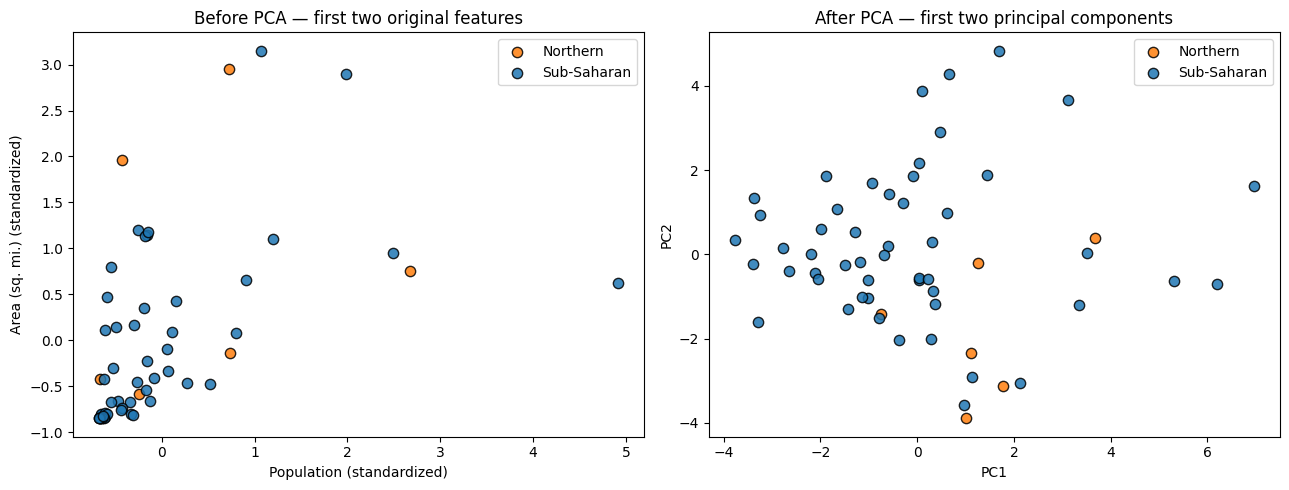

In [12]:
region_short = np.array(["Northern" if "NORTHERN" in r.upper() else "Sub-Saharan"
                         for r in region])
palette = {"Northern": "tab:orange", "Sub-Saharan": "tab:blue"}

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# BEFORE: first two standardized features
for reg, col in palette.items():
    m = region_short == reg
    ax[0].scatter(standardized_data[m, 0], standardized_data[m, 1],
                  c=col, label=reg, alpha=0.85, edgecolor="k", s=55)
ax[0].set_xlabel(f"{feature_names[0]} (standardized)")
ax[0].set_ylabel(f"{feature_names[1]} (standardized)")
ax[0].set_title("Before PCA — first two original features"); ax[0].legend()

# AFTER: first two principal components
for reg, col in palette.items():
    m = region_short == reg
    ax[1].scatter(reduced_data[m, 0], reduced_data[m, 1],
                  c=col, label=reg, alpha=0.85, edgecolor="k", s=55)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].set_title("After PCA — first two principal components"); ax[1].legend()

plt.tight_layout(); plt.show()

In [13]:
# Quantify the information lost: reconstruct from the kept components and measure error
reconstructed = reduced_data @ W.T
reconstruction_mse = np.mean((standardized_data - reconstructed) ** 2)
retained = cumulative_variance[num_components - 1]
print(f"Components kept       : {num_components} of {standardized_data.shape[1]}")
print(f"Variance retained     : {retained:.2%}")
print(f"Variance (information) lost : {1 - retained:.2%}")
print(f"Reconstruction MSE    : {reconstruction_mse:.4f}")

# Loadings: which original features define PC1 and PC2?
for pc in range(2):
    print(f"\nTop features defining PC{pc+1}:")
    for i in np.argsort(np.abs(sorted_eigenvectors[:, pc]))[::-1][:5]:
        print(f"  {feature_names[i]:35s} {sorted_eigenvectors[i, pc]:+.3f}")

Components kept       : 10 of 18
Variance retained     : 92.56%
Variance (information) lost : 7.44%
Reconstruction MSE    : 0.0744

Top features defining PC1:
  Infant mortality (per 1000 births)  -0.379
  Phones (per 1000)                   +0.358
  Birthrate                           -0.346
  GDP ($ per capita)                  +0.298
  Service                             +0.278

Top features defining PC2:
  Other (%)                           -0.434
  Arable (%)                          +0.373
  Industry                            -0.317
  Crops (%)                           +0.312
  Pop. Density (per sq. mi.)          +0.306


### Written answers (max 5 lines each)

**1. Interpretation of the before/after visual.**
Before PCA the two raw features (`Population`, `Area`) show little structure — most
countries cluster near the origin with a few large outliers, and the regions overlap.
After PCA, PC1 and PC2 spread the countries along meaningful, uncorrelated axes and the
two regions separate more clearly, because PCA rotates the data onto the directions that
carry the most variance instead of arbitrary original units.

**2. Why this number of components, and the trade-offs.**
At a 90% threshold the selector keeps **10 of 18** components. Variance here is *diffuse*
— PC1 holds only ~29% and the first two only ~48% — so aggressive reduction would discard
real signal; the trade-off is compression vs. fidelity: fewer components mean a smaller,
faster, less-noisy representation but more lost detail, while more components preserve
detail at the cost of dimensionality. Ten components balances the two (≈44% fewer features
while keeping 90% of the variance).

**3. What information is lost for this use case (economic activity & population pressure).**
The dropped components are low-variance directions, i.e. the fine-grained differences that
distinguish otherwise-similar countries — small contrasts in land-use mix (`Crops` vs
`Arable`), coastline, or climate. We keep the dominant economic-activity-vs-population-pressure
gradient (GDP, phones, services vs. birth/infant-mortality rates) but lose the subtle,
country-specific deviations from it, so two nations with similar development levels become
nearly indistinguishable in the reduced space.


## Task 3: Optimize the implementation & benchmark on large data

Three NumPy-only implementations of the same PCA:

1. **`pca_naive`** — covariance built with an explicit double `for`-loop and `np.linalg.eig`
   (a deliberately slow baseline).
2. **`pca_vectorized`** — covariance as a single matrix product $Z^{\top}Z/(n-1)$ and the
   symmetric solver `np.linalg.eigh`.
3. **`pca_svd`** — skips forming the covariance matrix entirely and takes the SVD of the
   centred/scaled data, which is the most numerically stable route and scales best when the
   number of features is large.

**Handling large datasets:** the vectorized and SVD paths avoid Python-level loops; mean
and standard deviation can also be accumulated in chunks for data too large to fit in
memory, so only a small block is resident at a time.

In [14]:
def _standardize(X):
    mu = X.mean(axis=0); sd = X.std(axis=0); sd[sd == 0] = 1.0
    return (X - mu) / sd

def pca_naive(X, n_components):
    Z = _standardize(X)
    n, d = Z.shape
    cov = np.zeros((d, d))
    for i in range(d):                       # explicit loops = slow baseline
        for j in range(d):
            cov[i, j] = np.sum(Z[:, i] * Z[:, j]) / (n - 1)
    vals, vecs = np.linalg.eig(cov)
    order = np.argsort(vals.real)[::-1]
    W = vecs[:, order[:n_components]].real
    return Z @ W

def pca_vectorized(X, n_components):
    Z = _standardize(X)
    n = Z.shape[0]
    cov = (Z.T @ Z) / (n - 1)                # single matrix product
    vals, vecs = np.linalg.eigh(cov)         # symmetric solver
    order = np.argsort(vals)[::-1]
    W = vecs[:, order[:n_components]]
    return Z @ W

def pca_svd(X, n_components):
    Z = _standardize(X)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)   # no covariance matrix formed
    W = Vt[:n_components].T
    return Z @ W

# sanity check: all three recover the same subspace (variance per PC matches; sign may flip)
r_vec = pca_vectorized(X, num_components)
r_svd = pca_svd(X, num_components)
print("Per-component variance (vectorized):", np.var(r_vec, axis=0).round(4))
print("Per-component variance (SVD)       :", np.var(r_svd, axis=0).round(4))

Per-component variance (vectorized): [5.142  3.4279 1.6265 1.5361 1.1749 0.9567 0.8826 0.7296 0.6299 0.5553]
Per-component variance (SVD)       : [5.142  3.4279 1.6265 1.5361 1.1749 0.9567 0.8826 0.7296 0.6299 0.5553]


In [15]:
# Benchmark on a larger synthetic matrix (2000 samples x 200 features)
rng = np.random.default_rng(0)
big = rng.standard_normal((2000, 200))
K = 10

def timeit(fn, *args, reps=10):
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(*args)
    return (time.perf_counter() - t0) / reps * 1000   # ms per run

results = {}
for name, fn in [("naive (loops + eig)", pca_naive),
                 ("vectorized (eigh)",   pca_vectorized),
                 ("svd",                 pca_svd)]:
    results[name] = timeit(fn, big, K)

print(f"Benchmark on {big.shape[0]}x{big.shape[1]} matrix, keeping {K} components:\n")
base = results["naive (loops + eig)"]
for name, ms in results.items():
    print(f"  {name:22s}: {ms:8.2f} ms / run   ({base/ms:5.1f}x vs naive)")

Benchmark on 2000x200 matrix, keeping 10 components:

  naive (loops + eig)   :   316.64 ms / run   (  1.0x vs naive)
  vectorized (eigh)     :    11.16 ms / run   ( 28.4x vs naive)
  svd                   :    46.61 ms / run   (  6.8x vs naive)


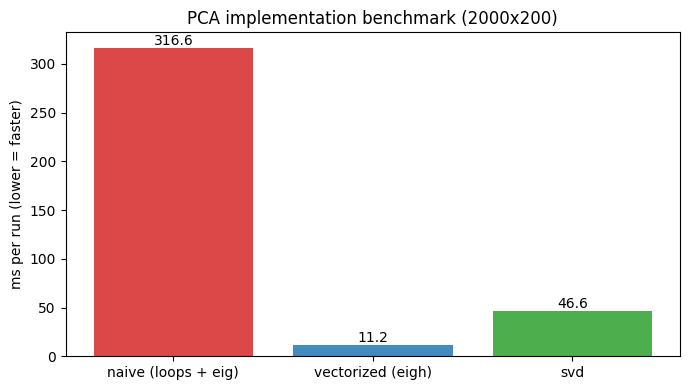

In [16]:
# Visualize the speed-up
names = list(results.keys()); times = list(results.values())
plt.figure(figsize=(7, 4))
bars = plt.bar(names, times, color=["tab:red", "tab:blue", "tab:green"], alpha=0.85)
plt.ylabel("ms per run (lower = faster)")
plt.title(f"PCA implementation benchmark ({big.shape[0]}x{big.shape[1]})")
for b, t in zip(bars, times):
    plt.text(b.get_x()+b.get_width()/2, t, f"{t:.1f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

### Optimization notes (max 5 lines)
Replacing the $O(d^2)$ Python double-loop with a single $Z^{\top}Z$ matrix product moves
the work into BLAS, giving a large speed-up, and `eigh` exploits symmetry for a further
gain over `eig`. The SVD route avoids forming and squaring the covariance matrix, so it is
the most numerically stable and the most efficient when features are many. For data that
does not fit in memory, the mean/standard-deviation pass can be accumulated in chunks, and
only the small $d \times d$ covariance (or a streaming/randomized SVD) need ever be held.